# FPro Score Prediction from Nutrition Facts & Ingredients

**Erdos Institute Data Science Boot Camp 2026 — Final Project**

## Project Goal
Learn a relationship between food **nutrition facts / ingredients** and the **FPro processing score**, then use the trained model to assess food processing levels on new datasets (e.g., French CIQUAL).

---

## What is FPro? (from the FoodProX model, Nature Communications 2023)

The **FPro score** is a continuous measure of food processing level (0 to 1) computed by the **FoodProX** machine learning model. It is derived as follows:

1. A Random Forest classifier is trained on USDA foods with expert NOVA labels (1-4) using 12 standard nutrient values.
2. For each food product, the model outputs 4 class probabilities: P(NOVA 1), P(NOVA 2), P(NOVA 3), P(NOVA 4).
3. The **FPro score** is computed as:

$$\text{FPro} = \frac{1 - P(\text{NOVA 1}) + P(\text{NOVA 4})}{2}$$

- **FPro close to 0** → Unprocessed (high P(NOVA 1), low P(NOVA 4))
- **FPro close to 1** → Ultra-processed (low P(NOVA 1), high P(NOVA 4))

## What is FPro Class?

The **`f_FPro_class`** (0–3) is the NOVA class with the **highest predicted probability**, shifted by 1:

| f_FPro_class | NOVA Class | Meaning | Typical FPro Range |
|:---:|:---:|---|---|
| 0 | NOVA 1 | Unprocessed / natural foods | ~0.0 – 0.50 |
| 1 | NOVA 2 | Processed culinary ingredients | ~0.33 – 0.73 |
| 2 | NOVA 3 | Processed foods | ~0.29 – 0.72 |
| 3 | NOVA 4 | Ultra-processed food products | ~0.50 – 1.00 |

**Important:** The classes are NOT defined by simple FPro thresholds — they overlap in FPro range because class assignment depends on the full probability distribution, not just the composite FPro score.

## Approaches

### This notebook (01): Ingredient-based Analysis
1. **Ingredient Rank Regression** — use ingredient list position (rank) to predict FPro (continuous)
2. **Binary Ingredient Classification** — use ingredient presence/absence to classify FPro class
3. **Price Correlation** — explore `price per calorie` vs FPro (supplementary)

### Notebook 02: Nutrition-based Modeling (main model)
4. **Nutrition → FPro** — use the 12 standard nutrition label nutrients to predict FPro score. This is the core model because nutrition data is universally available and can be applied cross-culturally (e.g., French CIQUAL dataset).

## Data Sources
| File | Description | Key Columns |
|---|---|---|
| `GroceryDB_foods.csv` | ~50K products with FPro + nutrition | `f_FPro`, `f_FPro_class`, `price percal`, 12 nutrients |
| `GroceryDB_data_uncurated.csv` | ~54K products with ingredient lists | `Original_ID`, `Ingredients` |
| `GroceryDB_IgFPro.csv` | Per-ingredient processing scores | `general_name`, `ingred_FPro` |

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from pathlib import Path
from collections import Counter
from scipy import stats

from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    r2_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

DATA_DIR = Path('../GroceryDB-main/data')
OUT_DIR  = Path('.')

plt.style.use('seaborn-v0_8-whitegrid')
NOVA_COLORS = {0: '#2ca02c', 1: '#1f77b4', 2: '#ff7f0e', 3: '#d62728'}
CLASS_LABELS = {0: 'Unprocessed', 1: 'Min. Processed', 2: 'Processed', 3: 'Ultra-Processed'}
STORE_COLORS = {'Walmart': '#fdbb30', 'Target': '#cc0001', 'WholeFoods': '#006f46'}

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load & Merge Data

In [2]:
foods  = pd.read_csv(DATA_DIR / 'GroceryDB_foods.csv')
unc    = pd.read_csv(DATA_DIR / 'GroceryDB_data_uncurated.csv')
igfpro = pd.read_csv(DATA_DIR / 'GroceryDB_IgFPro.csv')

print(f'foods shape:     {foods.shape}')
print(f'uncurated shape: {unc.shape}')
print(f'igfpro shape:    {igfpro.shape}')

foods shape:     (50468, 27)
uncurated shape: (54293, 5)
igfpro shape:    (10361, 4)


In [3]:
# Merge on original_ID — include Category from uncurated data
df = foods.merge(
    unc[['Original_ID', 'Ingredients', 'Category']],
    left_on='original_ID', right_on='Original_ID', how='inner'
).drop(columns='Original_ID')

# Rename to avoid confusion with harmonized category
df.rename(columns={'Category': 'store_category'}, inplace=True)

# Keep only rows with both FPro and Ingredients
df_clean = df.dropna(subset=['f_FPro', 'Ingredients']).copy()
df_clean['f_FPro_class'] = df_clean['f_FPro_class'].astype(int)

print(f'Merged:          {df.shape[0]:,} products')
print(f'With FPro score: {df["f_FPro"].notna().sum():,}')
print(f'Working dataset: {df_clean.shape[0]:,} products (FPro + Ingredients)')
print(f'Unique store categories: {df_clean["store_category"].nunique()}')
print(f'Unique harmonized categories: {df_clean["harmonized single category"].nunique()}')

Merged:          46,890 products
With FPro score: 26,012
Working dataset: 26,012 products (FPro + Ingredients)
Unique store categories: 149
Unique harmonized categories: 53


---
## 2. EDA

### 2a. FPro Score Distribution

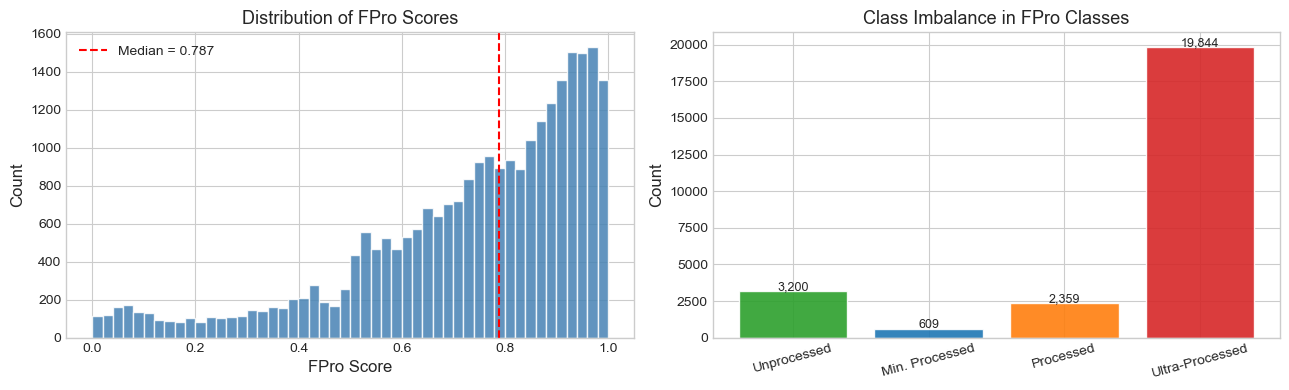

              count      mean       min       max
f_FPro_class                                     
0              3200  0.257816  0.000000  0.499843
1               609  0.560183  0.326500  0.729093
2              2359  0.566433  0.294167  0.722582
3             19844  0.830862  0.500005  0.999056


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of continuous FPro
ax = axes[0]
ax.hist(df_clean['f_FPro'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('FPro Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of FPro Scores', fontsize=13)
ax.axvline(df_clean['f_FPro'].median(), color='red', ls='--',
           label=f'Median = {df_clean["f_FPro"].median():.3f}')
ax.legend()

# Bar chart of class counts
ax = axes[1]
counts = df_clean['f_FPro_class'].value_counts().sort_index()
bars = ax.bar([CLASS_LABELS[i] for i in counts.index], counts.values,
              color=[NOVA_COLORS[i] for i in counts.index], edgecolor='white', alpha=0.9)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontsize=9)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Class Imbalance in FPro Classes', fontsize=13)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fpro_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_clean.groupby('f_FPro_class')['f_FPro'].agg(['count','mean','min','max']))

### 2b. FPro by Store

The data covers three major US grocery chains: **Walmart**, **Target**, and **Whole Foods**.  
Do they differ in processing levels?

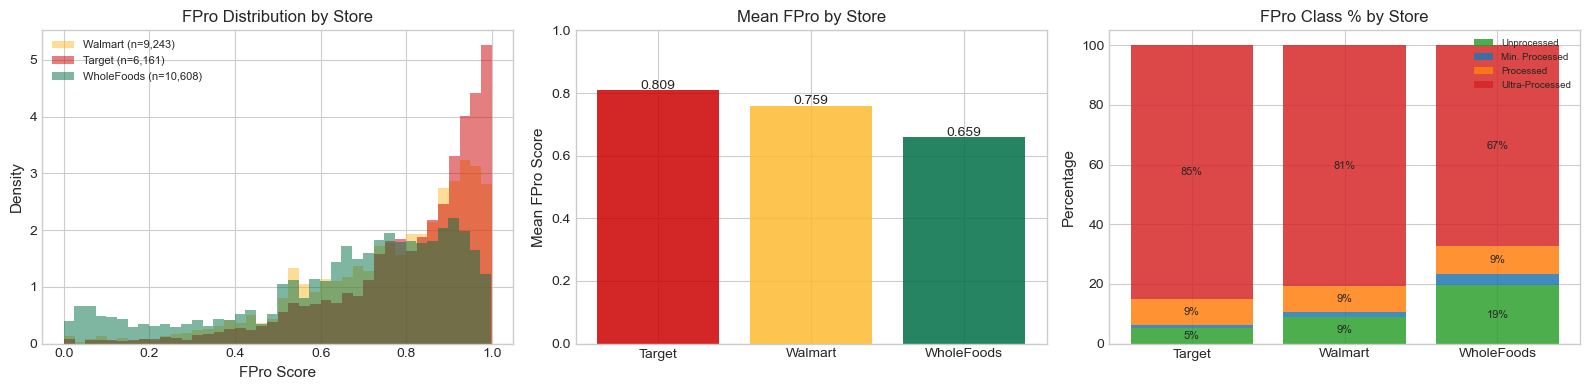

                mean    median  count
store                                
Target      0.809100  0.867317   6161
Walmart     0.758598  0.809389   9243
WholeFoods  0.659258  0.723417  10608


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# FPro histogram by store
ax = axes[0]
for store in ['Walmart', 'Target', 'WholeFoods']:
    subset = df_clean[df_clean['store'] == store]['f_FPro']
    ax.hist(subset, bins=40, alpha=0.5, label=f'{store} (n={len(subset):,})',
            color=STORE_COLORS[store], density=True)
ax.set_xlabel('FPro Score', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('FPro Distribution by Store', fontsize=12)
ax.legend(fontsize=8)

# Mean FPro by store
ax = axes[1]
store_stats = df_clean.groupby('store')['f_FPro'].agg(['mean','median','count'])
store_stats = store_stats.sort_values('mean', ascending=False)
colors_s = [STORE_COLORS[s] for s in store_stats.index]
bars = ax.bar(store_stats.index, store_stats['mean'], color=colors_s, alpha=0.85)
for bar, val in zip(bars, store_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=10)
ax.set_ylabel('Mean FPro Score', fontsize=11)
ax.set_title('Mean FPro by Store', fontsize=12)
ax.set_ylim(0, 1)

# Class distribution by store (stacked %)
ax = axes[2]
store_class = df_clean.groupby(['store', 'f_FPro_class']).size().unstack(fill_value=0)
store_pct = store_class.div(store_class.sum(axis=1), axis=0) * 100
store_pct = store_pct.loc[['Target', 'Walmart', 'WholeFoods']]
bottom = np.zeros(len(store_pct))
for cls in range(4):
    vals = store_pct[cls].values
    ax.bar(store_pct.index, vals, bottom=bottom, color=NOVA_COLORS[cls],
           label=CLASS_LABELS[cls], alpha=0.85)
    for j, (b, v) in enumerate(zip(bottom, vals)):
        if v > 4:
            ax.text(j, b + v/2, f'{v:.0f}%', ha='center', va='center', fontsize=8)
    bottom += vals
ax.set_ylabel('Percentage', fontsize=11)
ax.set_title('FPro Class % by Store', fontsize=12)
ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fpro_by_store.png', dpi=150, bbox_inches='tight')
plt.show()

print(store_stats)

### Interpretation — Store Analysis

- **Whole Foods** has the lowest mean FPro (least processed on average), consistent with its brand positioning as a health-focused grocery store.
- **Target** has the highest mean FPro (most ultra-processed products).
- The stacked bar chart shows Whole Foods has a larger share of unprocessed (class 0) and processed (class 2) products, while Target and Walmart are dominated by ultra-processed (class 3).

### 2c. FPro by Food Category

The uncurated data includes a **`Category`** column (173 store-level categories like "VEGETABLES/PACKAGED VEG", "SNACKS", "DAIRY") from the original grocery store websites.  
The foods data also has a **`harmonized single category`** (53 clean categories harmonized across stores).  
We analyze both below.

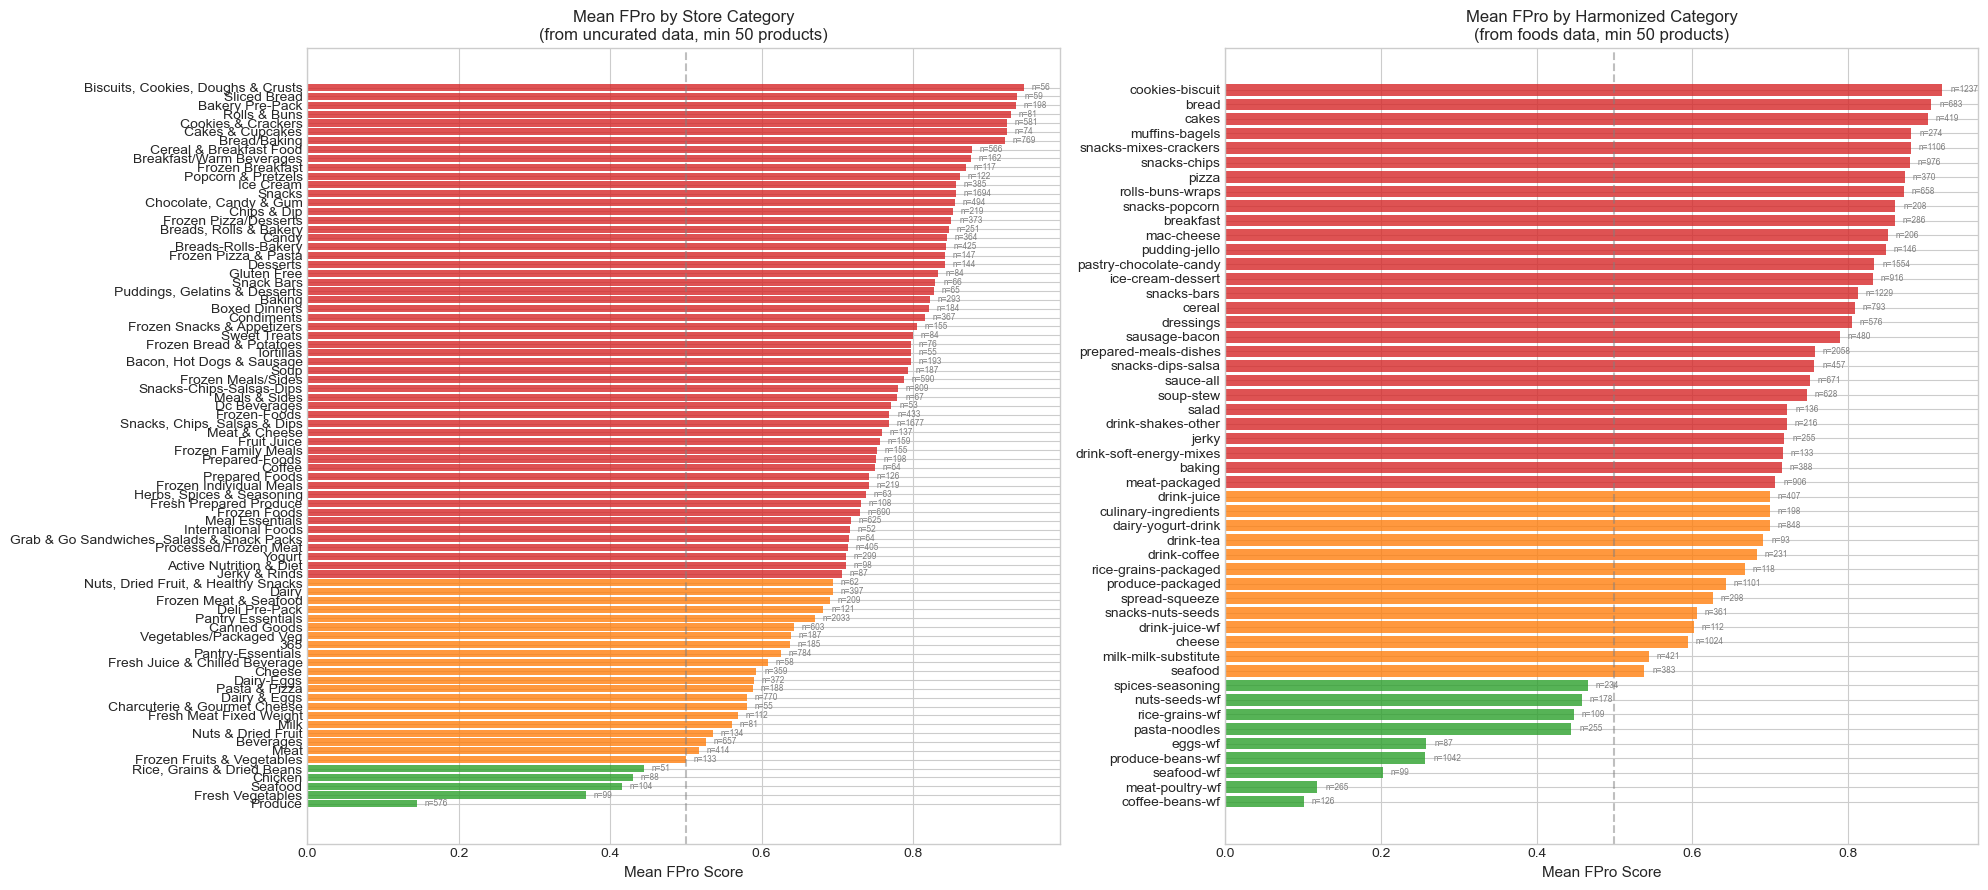

Store categories shown: 82 (of 144 total)
Harmonized categories shown: 50 (of 53 total)

Store category — least processed:
                                mean  count
store_category                             
Produce                     0.144800    576
Fresh Vegetables            0.368230     99
Seafood                     0.416110    104
Chicken                     0.430283     88
Rice, Grains & Dried Beans  0.444218     51

Store category — most processed:
                                        mean  count
store_category                                     
Cookies & Crackers                  0.924565    581
Rolls & Buns                        0.929644     81
Bakery Pre-Pack                     0.935637    198
Sliced Bread                        0.936880     59
Biscuits, Cookies, Doughs & Crusts  0.947144     56


In [6]:
# Normalise store_category capitalisation ('produce' / 'PRODUCE' -> 'Produce')
df_clean['store_category'] = df_clean['store_category'].str.strip().str.title()

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# --- Left: Store Category (from uncurated data) ---
ax = axes[0]
scat_stats = df_clean.groupby('store_category')['f_FPro'].agg(['mean','count'])
scat_stats = scat_stats[scat_stats['count'] >= 50].sort_values('mean', ascending=True)
colors_sc = ['#d62728' if m > 0.7 else '#ff7f0e' if m > 0.5 else '#2ca02c'
             for m in scat_stats['mean']]
ax.barh(scat_stats.index, scat_stats['mean'], color=colors_sc, alpha=0.8)
ax.set_xlabel('Mean FPro Score', fontsize=11)
ax.set_title('Mean FPro by Store Category\n(from uncurated data, min 50 products)', fontsize=12)
ax.axvline(0.5, color='gray', ls='--', alpha=0.5)
for i, (cat, row) in enumerate(scat_stats.iterrows()):
    ax.text(row['mean'] + 0.01, i, f'n={int(row["count"])}', va='center', fontsize=6, color='gray')

# --- Right: Harmonized Category (from foods data) ---
ax = axes[1]
cat_stats = df_clean.groupby('harmonized single category')['f_FPro'].agg(['mean','count'])
cat_stats = cat_stats[cat_stats['count'] >= 50].sort_values('mean', ascending=True)
colors_bar = ['#d62728' if m > 0.7 else '#ff7f0e' if m > 0.5 else '#2ca02c'
              for m in cat_stats['mean']]
ax.barh(cat_stats.index, cat_stats['mean'], color=colors_bar, alpha=0.8)
ax.set_xlabel('Mean FPro Score', fontsize=11)
ax.set_title('Mean FPro by Harmonized Category\n(from foods data, min 50 products)', fontsize=12)
ax.axvline(0.5, color='gray', ls='--', alpha=0.5)
for i, (cat, row) in enumerate(cat_stats.iterrows()):
    ax.text(row['mean'] + 0.01, i, f'n={int(row["count"])}', va='center', fontsize=6, color='gray')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fpro_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Store categories shown: {len(scat_stats)} (of {df_clean["store_category"].nunique()} total)')
print(f'Harmonized categories shown: {len(cat_stats)} (of {df_clean["harmonized single category"].nunique()} total)')
print('\nStore category — least processed:')
print(scat_stats.head(5)[['mean','count']])
print('\nStore category — most processed:')
print(scat_stats.tail(5)[['mean','count']])

### Interpretation — Category Analysis

**Store Category (left, from uncurated data):** These are the raw category labels from each grocery store's website (e.g., "VEGETABLES/PACKAGED VEG", "SNACKS", "DAIRY"). They are more granular (173 unique) and store-specific.

**Harmonized Category (right, from foods data):** These are 53 cleaned categories that standardize naming across Walmart, Target, and Whole Foods.

**Key findings (both charts):**
- **Least processed** (green bars): produce, vegetables, beans, meat, cheese, eggs — fresh whole foods as expected.
- **Most processed** (red bars): candy, soda/energy drinks, cookies, pastry — snack and confectionery categories.
- This confirms FPro captures intuitive processing differences across food categories.
- The wide range (mean FPro from ~0.2 to ~0.95 across categories) means **food category is a strong predictor of FPro** — potentially useful as a feature in modeling.

### 2d. Number of Ingredients vs. FPro

In [7]:
# Ingredient name normalisation — applied at parse time so every downstream
# cell (ingred_counts, top_k matrix, rank matrix) benefits automatically.
#
# Two fixes:
#   a) Dots (and other non-alphanumeric chars) are now stripped from ingredient
#      names, so "salt." and "salt" collapse to the same token.
#   b) Semantic synonyms are unified via INGREDIENT_NORM.  Sea salt, kosher
#      salt, etc. are all just "salt" for our processing-level analysis.
INGREDIENT_NORM = {
    # salt variants
    'sea salt':          'salt',
    'kosher salt':       'salt',
    'table salt':        'salt',
    'iodized salt':      'salt',
    'fine sea salt':     'salt',
    'coarse sea salt':   'salt',
}

# Parse ingredients first (needed for this plot and all later sections)
def parse_ingredients(text):
    """Parse raw ingredient string into list of cleaned, normalised names.

    Steps:
      1. Lower-case
      2. Strip parenthetical sub-ingredients  e.g. (ascorbic acid)
      3. Split on comma / semicolon
      4. Remove all non-alphanumeric chars incl. dots  -> no more 'salt.'
      5. Apply INGREDIENT_NORM synonym map
    """
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'\([^)]*\)', '', text)   # remove sub-ingredients in parens
    parts = re.split(r'[,;]', text)
    cleaned = []
    for p in parts:
        p = re.sub(r'[^a-z0-9 %\-]', ' ', p).strip()   # dots removed here
        p = ' '.join(p.split())
        if len(p) >= 2:
            cleaned.append(INGREDIENT_NORM.get(p, p))      # apply synonym map
    return cleaned

df_clean['ingred_list'] = df_clean['Ingredients'].apply(parse_ingredients)
df_clean['n_ingredients'] = df_clean['ingred_list'].apply(len)

print(f'Average ingredients per product: {df_clean["n_ingredients"].mean():.1f}')
print(f'Median:  {df_clean["n_ingredients"].median():.0f}')
print(f'Products with 0 parsed ingredients: {(df_clean["n_ingredients"] == 0).sum()}')


Average ingredients per product: 11.5
Median:  10
Products with 0 parsed ingredients: 1


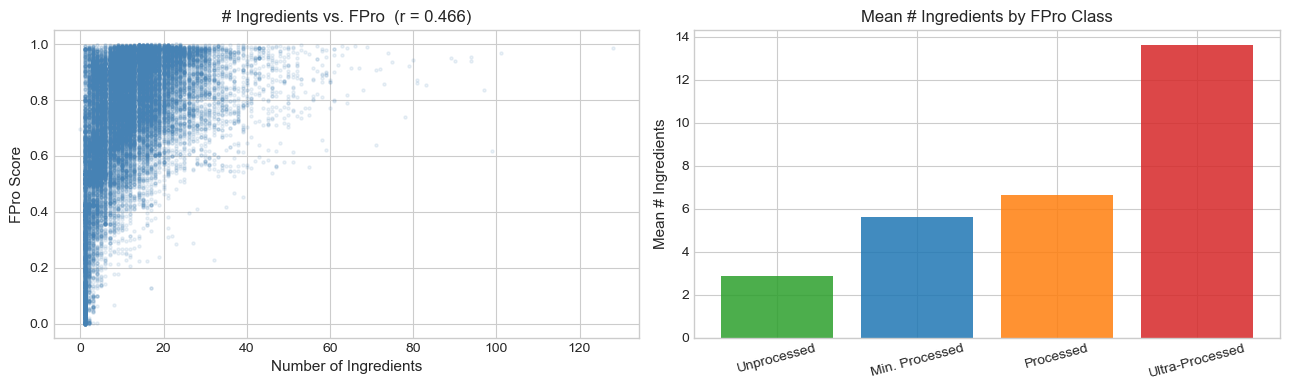

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(df_clean['n_ingredients'], df_clean['f_FPro'], alpha=0.1, s=5, color='steelblue')
r_ni, _ = stats.pearsonr(df_clean['n_ingredients'], df_clean['f_FPro'])
ax.set_xlabel('Number of Ingredients', fontsize=11)
ax.set_ylabel('FPro Score', fontsize=11)
ax.set_title(f'# Ingredients vs. FPro  (r = {r_ni:.3f})', fontsize=12)

ax = axes[1]
class_n = df_clean.groupby('f_FPro_class')['n_ingredients'].mean()
ax.bar([CLASS_LABELS[c] for c in class_n.index], class_n.values,
       color=[NOVA_COLORS[c] for c in class_n.index], alpha=0.85)
ax.set_ylabel('Mean # Ingredients', fontsize=11)
ax.set_title('Mean # Ingredients by FPro Class', fontsize=12)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(OUT_DIR / 'n_ingredients_vs_fpro.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation — Number of Ingredients vs. FPro

- **r = 0.47**: Moderate positive correlation — products with **more ingredients tend to be more processed**.
- Unprocessed foods (e.g., raw chicken) have ~5 ingredients; ultra-processed (e.g., frozen pizza) have ~13.
- However, ingredient count alone is insufficient — some products with few ingredients can be highly processed (e.g., "high fructose corn syrup" is 1 ingredient, FPro near 1.0). This is why we need to look at *which* ingredients are present.

---
## 3. Price vs. FPro Correlation

Are more processed foods cheaper or more expensive per calorie?

**Where is the price data?** The column `price percal` ($/kcal) is in `GroceryDB_foods.csv`. ~24K products are missing price data.

**What are Pearson and Spearman correlations?**
- **Pearson r** measures *linear* correlation (-1 to +1). r = 0 means no linear trend.
- **Spearman rho** measures *monotonic* (rank-based) correlation. More robust to outliers.
- The **p-value** tells us if the result is statistically significant (p < 0.05 = significant).

In [9]:
price_df = df_clean.dropna(subset=['price percal']).copy()
q99 = price_df['price percal'].quantile(0.99)
price_df = price_df[price_df['price percal'] < q99]

pearson_r,  pearson_p  = stats.pearsonr(price_df['price percal'], price_df['f_FPro'])
spearman_r, spearman_p = stats.spearmanr(price_df['price percal'], price_df['f_FPro'])
print(f'Price analysis: {price_df.shape[0]:,} products')
print(f'Pearson  r = {pearson_r:.4f}  (p = {pearson_p:.2e})')
print(f'Spearman r = {spearman_r:.4f}  (p = {spearman_p:.2e})')

Price analysis: 20,295 products
Pearson  r = -0.2457  (p = 9.90e-277)
Spearman r = -0.3528  (p = 0.00e+00)


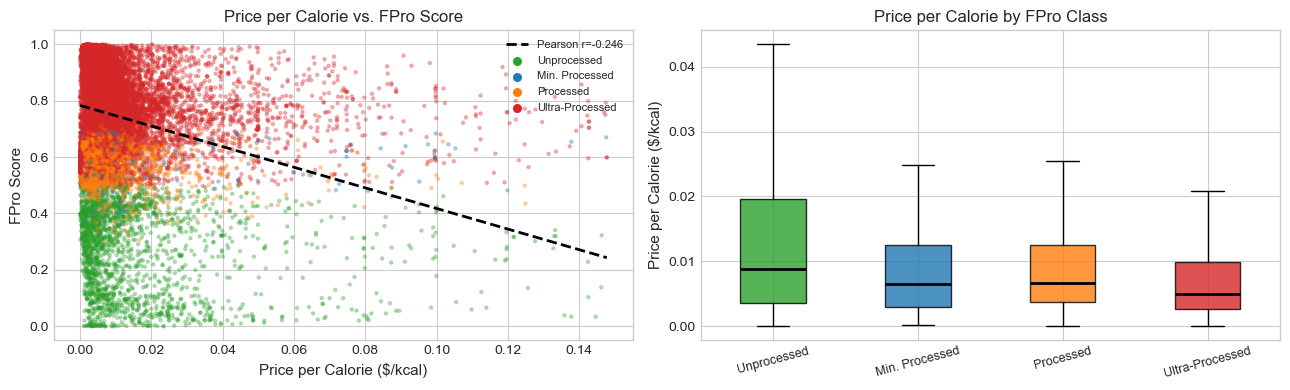

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(price_df['price percal'], price_df['f_FPro'],
           c=[NOVA_COLORS[c] for c in price_df['f_FPro_class']], alpha=0.3, s=5)
m, b = np.polyfit(price_df['price percal'], price_df['f_FPro'], 1)
x_range = np.linspace(price_df['price percal'].min(), price_df['price percal'].max(), 200)
ax.plot(x_range, m*x_range + b, 'k--', lw=2, label=f'Pearson r={pearson_r:.3f}')
ax.set_xlabel('Price per Calorie ($/kcal)', fontsize=11)
ax.set_ylabel('FPro Score', fontsize=11)
ax.set_title('Price per Calorie vs. FPro Score', fontsize=12)
for cls, lbl in CLASS_LABELS.items():
    ax.scatter([], [], c=NOVA_COLORS[cls], label=lbl, s=30)
ax.legend(fontsize=8, loc='upper right')

ax = axes[1]
bp = ax.boxplot([price_df[price_df['f_FPro_class']==c]['price percal'].values for c in range(4)],
                patch_artist=True, medianprops=dict(color='black', lw=2), showfliers=False)
for patch, c in zip(bp['boxes'], range(4)):
    patch.set_facecolor(NOVA_COLORS[c]); patch.set_alpha(0.8)
ax.set_xticklabels([CLASS_LABELS[c] for c in range(4)], rotation=15, fontsize=9)
ax.set_ylabel('Price per Calorie ($/kcal)', fontsize=11)
ax.set_title('Price per Calorie by FPro Class', fontsize=12)

plt.tight_layout()
plt.savefig(OUT_DIR / 'price_vs_fpro.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
groups = [price_df[price_df['f_FPro_class']==c]['price percal'].values for c in range(4)]
f_stat, anova_p = stats.f_oneway(*groups)
print(f'One-way ANOVA:  F = {f_stat:.2f},  p = {anova_p:.2e}')
print('\nMean price per calorie by class:')
print(price_df.groupby('f_FPro_class')['price percal'].mean().rename(CLASS_LABELS))

One-way ANOVA:  F = 167.33,  p = 3.72e-107

Mean price per calorie by class:
f_FPro_class
Unprocessed        0.016248
Min. Processed     0.014311
Processed          0.010482
Ultra-Processed    0.009071
Name: price percal, dtype: float64


### Interpretation — Price vs. FPro

- **Pearson r = -0.25, Spearman r = -0.35**: Weak but highly significant negative correlation. Ultra-processed foods are **cheaper per calorie**.
- Unprocessed: ~$0.016/kcal vs Ultra-processed: ~$0.009/kcal — roughly **1.8x more expensive** to eat unprocessed.
- **ANOVA F = 167, p ≈ 0**: Price per calorie differs significantly across classes.
- **Limitation:** r = -0.25 explains only ~6% of variance. Price alone cannot predict processing level — it's a supplementary signal at best.

---
## 4. Ingredient Parsing & Top Ingredients

By food labeling law, ingredients are listed in **descending order of weight** — first ingredient = heaviest.

Total unique ingredients: 24,857

Example — Stonyfield Organic Whole Milk Strawberry Beet Berry Kids&#39
  Ingredients: ['cultured pasteurized organic whole milk', 'organic cane sugar', 'organic strawberry puree', 'organic beet puree', 'organic raspberry puree', 'pectin']


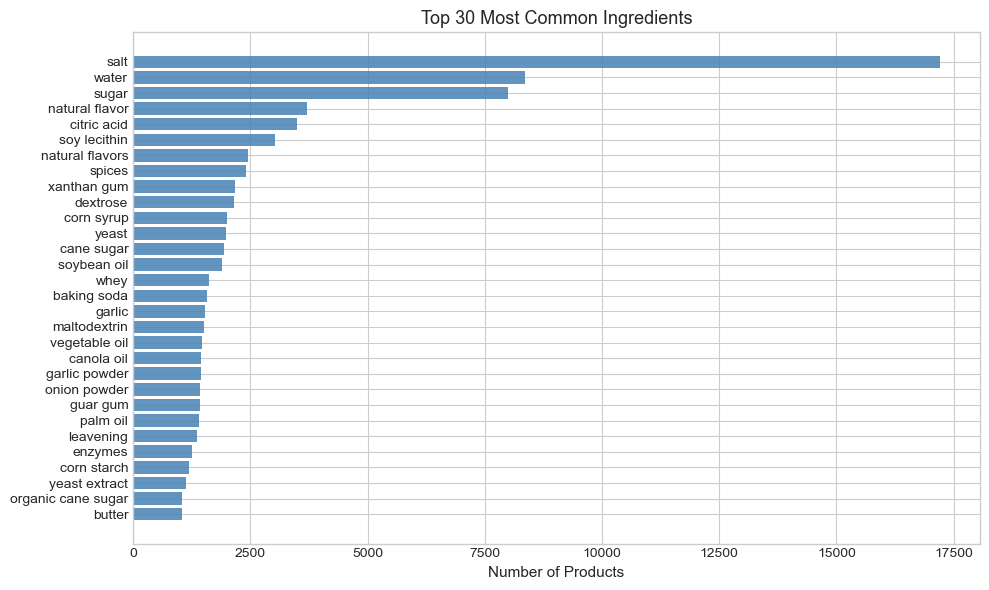

In [13]:
all_ingredients = [ing for lst in df_clean['ingred_list'] for ing in lst]
ingred_counts = Counter(all_ingredients)
print(f'Total unique ingredients: {len(ingred_counts):,}')

# Example
sample = df_clean[df_clean['n_ingredients'] > 5].iloc[0]
print(f'\nExample — {sample["name"][:60]}')
print(f'  Ingredients: {sample["ingred_list"][:6]}')

# Top 30 bar chart
top30 = pd.DataFrame(ingred_counts.most_common(30), columns=['ingredient', 'count'])
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top30['ingredient'][::-1], top30['count'][::-1], color='steelblue', alpha=0.85)
ax.set_xlabel('Number of Products', fontsize=11)
ax.set_title('Top 30 Most Common Ingredients', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'top_ingredients.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Approach 1 — Binary Ingredient Features → FPro Class

Each product becomes a binary vector: ingredient present (1) or absent (0).  
We restrict to the **top K most common ingredients** as features.

### Why do we need hundreds of ingredients, not just the top 5?

The top 5 (salt, water, sugar, etc.) appear in **both** processed and unprocessed foods.  
What matters is the **combination pattern** of many ingredients:
- **Ultra-processing markers**: high fructose corn syrup, palm oil, soy lecithin, artificial colors
- **Unprocessed markers**: almonds, garlic, olive oil, whole wheat

We verify this empirically with a TOP_K sweep later in Section 7.

In [14]:
TOP_K = 200

top_k_ingreds = [ing for ing, _ in ingred_counts.most_common(TOP_K)]
top_k_set = set(top_k_ingreds)

def make_binary_row(ingred_list):
    s = set(ingred_list)
    return [1 if ing in s else 0 for ing in top_k_ingreds]

print(f'Building binary matrix ({df_clean.shape[0]:,} x {TOP_K})...')
X_binary = np.array(df_clean['ingred_list'].apply(make_binary_row).tolist())
y_class  = df_clean['f_FPro_class'].values
y_fpro   = df_clean['f_FPro'].values
print(f'X_binary shape: {X_binary.shape}')
print(f'Class distribution: {dict(zip(*np.unique(y_class, return_counts=True)))}')

Building binary matrix (26,012 x 200)...
X_binary shape: (26012, 200)
Class distribution: {np.int64(0): np.int64(3200), np.int64(1): np.int64(609), np.int64(2): np.int64(2359), np.int64(3): np.int64(19844)}


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=20,
                                 class_weight='balanced', random_state=42, n_jobs=-1)
print('Running 5-fold CV — RF (binary features)...')
cv_f1  = cross_val_score(rf_clf, X_binary, y_class, cv=cv, scoring='f1_macro', n_jobs=-1)
cv_acc = cross_val_score(rf_clf, X_binary, y_class, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'  Macro F1 : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')
print(f'  Accuracy : {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')

# Logistic Regression
lr_clf = Pipeline([('scaler', StandardScaler()),
                    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced',
                                              random_state=42, n_jobs=-1))])
cv_lr_f1 = cross_val_score(lr_clf, X_binary, y_class, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'\nLogistic Regression Macro F1: {cv_lr_f1.mean():.4f} +/- {cv_lr_f1.std():.4f}')

Running 5-fold CV — RF (binary features)...
  Macro F1 : 0.5109 +/- 0.0019
  Accuracy : 0.7167 +/- 0.0025

Logistic Regression Macro F1: 0.4787 +/- 0.0041


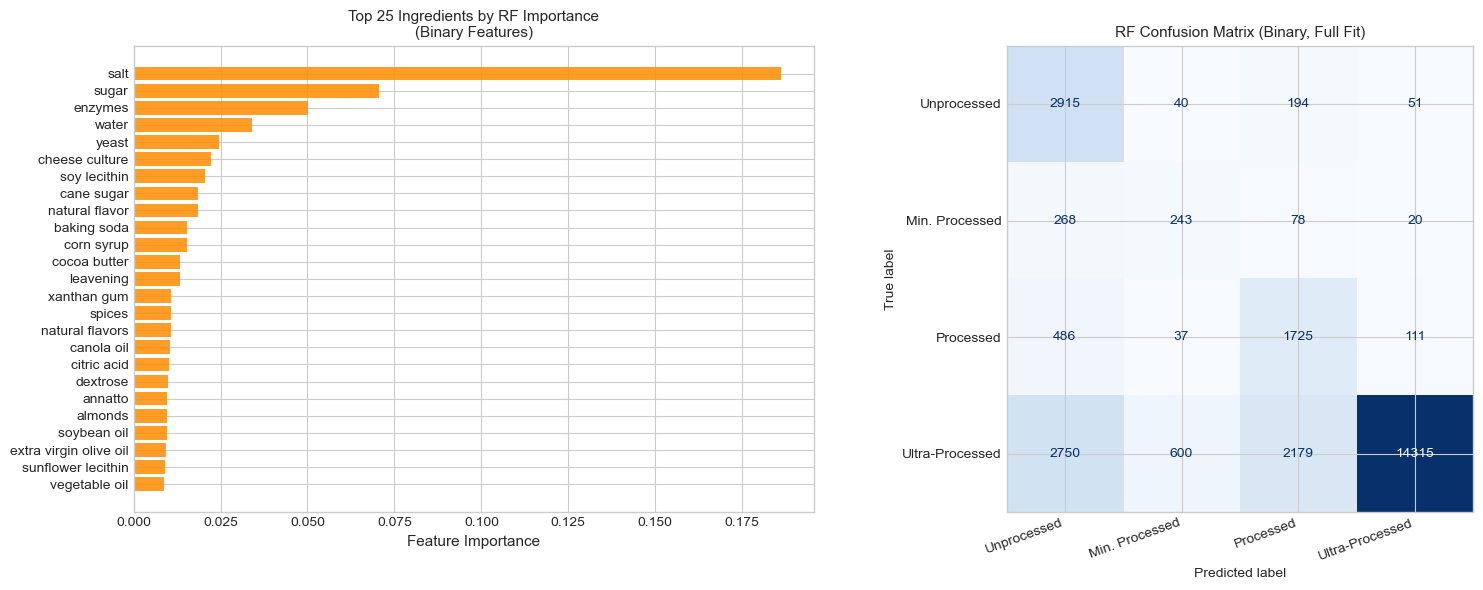

                 precision    recall  f1-score   support

    Unprocessed       0.45      0.91      0.61      3200
 Min. Processed       0.26      0.40      0.32       609
      Processed       0.41      0.73      0.53      2359
Ultra-Processed       0.99      0.72      0.83     19844

       accuracy                           0.74     26012
      macro avg       0.53      0.69      0.57     26012
   weighted avg       0.85      0.74      0.77     26012



In [16]:
# Fit on full data for feature importance + confusion matrix
rf_clf.fit(X_binary, y_class)
y_pred_rf = rf_clf.predict(X_binary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
ax = axes[0]
feat_imp = pd.DataFrame({'ingredient': top_k_ingreds,
                          'importance': rf_clf.feature_importances_})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(25)
ax.barh(feat_imp['ingredient'][::-1], feat_imp['importance'][::-1],
        color='darkorange', alpha=0.85)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Top 25 Ingredients by RF Importance\n(Binary Features)', fontsize=11)

# Confusion matrix
ax = axes[1]
cm = confusion_matrix(y_class, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[CLASS_LABELS[i] for i in range(4)])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('RF Confusion Matrix (Binary, Full Fit)', fontsize=11)
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig(OUT_DIR / 'binary_rf_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_class, y_pred_rf,
                             target_names=[CLASS_LABELS[i] for i in range(4)]))

### Interpretation — Binary Features (Approach 2)

**Confusion matrix:** Rows = true labels, Columns = predicted labels. Diagonal = correct.

- **Ultra-Processed (class 3)**: Easiest — 0.99 precision, 74% recall. When the model says ultra-processed, it's almost always right.
- **Min. Processed (class 1)**: Hardest — only 41% recall. This tiny class (609 products) overlaps heavily with classes 0 and 2.
- **Biggest error**: Ultra-processed products misclassified as unprocessed — likely products with short ingredient lists but highly processed contents.
- **Macro F1 = 0.51** (CV): The model captures real signal, but overlapping class boundaries limit accuracy.

**Note:** The confusion matrix above is fitted on full data (optimistic). The true metric is the 5-fold CV macro F1.

---
## 6. Approach 2 — Ingredient Rank Features → FPro Score

Instead of just 0/1, we encode each ingredient as **1/rank** (1st ingredient = 1.0, 2nd = 0.5, etc.).  
This encodes both *presence* and *importance* (earlier = heavier in the product).

**Target:** `f_FPro` (continuous 0–1 regression).

### 6a. Rank Feature Encoding & Regression

In [17]:
def make_rank_row(ingred_list):
    row = np.zeros(TOP_K)
    for rank, ing in enumerate(ingred_list, start=1):
        if ing in top_k_set:
            idx = top_k_ingreds.index(ing)
            row[idx] = 1.0 / rank
    return row

print(f'Building rank matrix ({df_clean.shape[0]:,} x {TOP_K})...')
X_rank = np.array(df_clean['ingred_list'].apply(make_rank_row).tolist())
print(f'X_rank shape: {X_rank.shape}')

Building rank matrix (26,012 x 200)...
X_rank shape: (26012, 200)


In [18]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# RF Regressor
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
print('Running 5-fold CV — RF Regressor (rank features)...')
cv_r2   = cross_val_score(rf_reg, X_rank, y_fpro, cv=cv_reg, scoring='r2', n_jobs=-1)
cv_rmse = cross_val_score(rf_reg, X_rank, y_fpro, cv=cv_reg,
                           scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f'  R2   : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
print(f'  RMSE : {(-cv_rmse).mean():.4f} +/- {(-cv_rmse).std():.4f}')

# Ridge Regression (linear baseline)
ridge = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])
cv_ridge_r2 = cross_val_score(ridge, X_rank, y_fpro, cv=cv_reg, scoring='r2', n_jobs=-1)
print(f'\nRidge Regression R2: {cv_ridge_r2.mean():.4f} +/- {cv_ridge_r2.std():.4f}')

Running 5-fold CV — RF Regressor (rank features)...
  R2   : 0.5196 +/- 0.0105
  RMSE : 0.1585 +/- 0.0015

Ridge Regression R2: 0.3608 +/- 0.0088


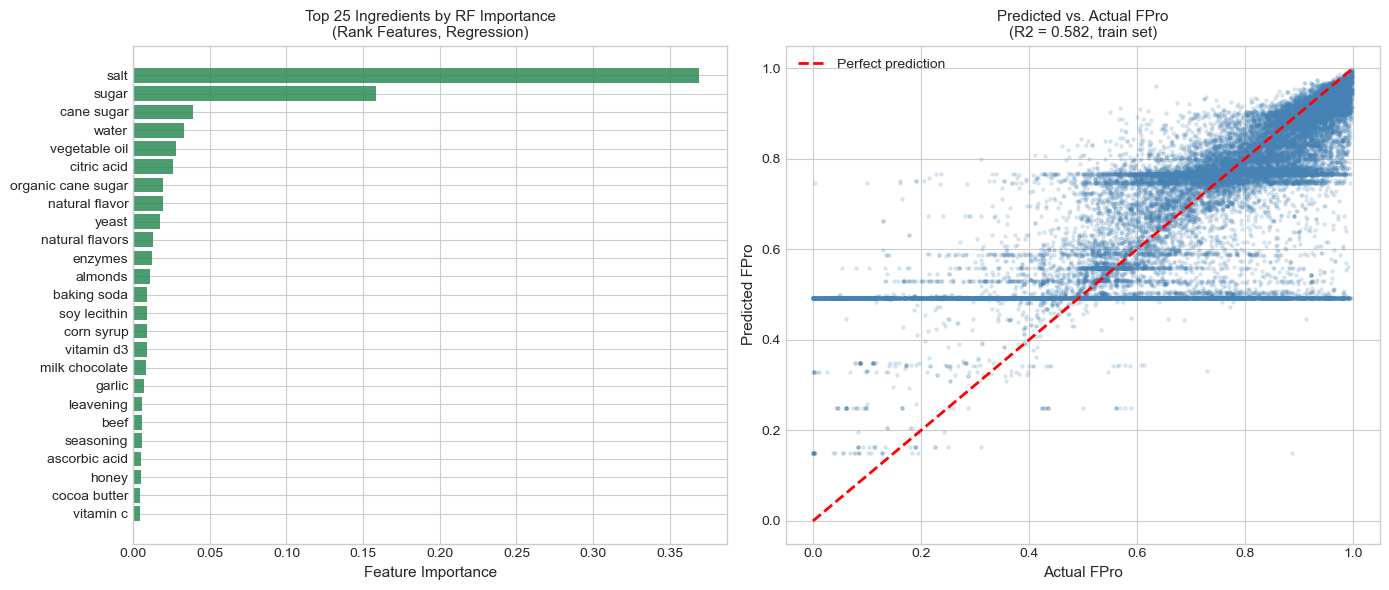

In [19]:
# Fit on full data for visualization
rf_reg.fit(X_rank, y_fpro)
y_pred_reg = rf_reg.predict(X_rank)

reg_imp = pd.DataFrame({'ingredient': top_k_ingreds,
                          'importance': rf_reg.feature_importances_})
reg_imp = reg_imp.sort_values('importance', ascending=False).head(25)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.barh(reg_imp['ingredient'][::-1], reg_imp['importance'][::-1],
        color='seagreen', alpha=0.85)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Top 25 Ingredients by RF Importance\n(Rank Features, Regression)', fontsize=11)

ax = axes[1]
ax.scatter(y_fpro, y_pred_reg, alpha=0.15, s=5, color='steelblue')
ax.plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual FPro', fontsize=11)
ax.set_ylabel('Predicted FPro', fontsize=11)
ax.set_title(f'Predicted vs. Actual FPro\n(R2 = {r2_score(y_fpro, y_pred_reg):.3f}, train set)', fontsize=11)
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'rank_rf_regression.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Quick verification: confirm 'sea salt' and 'salt.' are now unified
from collections import Counter
flat = [ing for lst in df_clean['ingred_list'] for ing in lst]
counts = Counter(flat)
for kw in ['salt', 'sea salt', 'kosher salt', 'iodized salt']:
    print(f'{kw!r:25s}: {counts.get(kw, 0):,} products')


'salt'                   : 17,201 products
'sea salt'               : 0 products
'kosher salt'            : 0 products
'iodized salt'           : 0 products


### Interpretation — Rank Regression (Approach 1)

**Feature importance (left):** Sugar, salt, and sea salt dominate — their position in the ingredient list is the strongest predictor. If sugar is listed 1st, the product is likely ultra-processed.

**Predicted vs Actual (right):**
- Points near the red line = good predictions. The model works well for high-FPro products (top-right cluster).
- **The horizontal band at ~0.5**: Products whose ingredient lists have very few matches in our top-200 set. With almost no signal, the model defaults to predicting the dataset mean. This is a limitation of the top-K approach.

**Overall:** R2 = 0.51 (CV) means ingredient rank explains about **half** the variance in FPro. Ridge R2 = 0.36 confirms the relationship is partly non-linear — trees capture it better.

### 6b. Rank vs Binary Comparison

In [21]:
rf_rank_clf = RandomForestClassifier(n_estimators=200, max_depth=20,
                                      class_weight='balanced', random_state=42, n_jobs=-1)
cv_rank_f1 = cross_val_score(rf_rank_clf, X_rank, y_class, cv=cv, scoring='f1_macro', n_jobs=-1)

print('=== Classification Macro F1 Comparison ===')
print(f'RF (Binary features) : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')
print(f'RF (Rank features)   : {cv_rank_f1.mean():.4f} +/- {cv_rank_f1.std():.4f}')
print(f'Logistic (Binary)    : {cv_lr_f1.mean():.4f} +/- {cv_lr_f1.std():.4f}')
print()
print('=> Rank > Binary: ingredient position adds useful information beyond presence/absence.')

=== Classification Macro F1 Comparison ===
RF (Binary features) : 0.5109 +/- 0.0019
RF (Rank features)   : 0.5347 +/- 0.0085
Logistic (Binary)    : 0.4787 +/- 0.0041

=> Rank > Binary: ingredient position adds useful information beyond presence/absence.


---
## 7. TOP_K Sensitivity — How Many Ingredients Do We Need?

We sweep TOP_K from 5 to 500 and measure performance.  
This empirically answers: **is top-5 enough, or do we need hundreds?**

In [22]:
topk_values = [5, 10, 20, 50, 100, 200, 500]
binary_f1_scores = []
rank_f1_scores = []
regression_r2_scores = []

cv_3f = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_3r = KFold(n_splits=3, shuffle=True, random_state=42)
all_top_ingreds = [ing for ing, _ in ingred_counts.most_common(max(topk_values))]

for k in topk_values:
    print(f'TOP_K = {k}...', end=' ')
    k_ingreds = all_top_ingreds[:k]
    k_set = set(k_ingreds)

    X_b = np.array([[1 if ing in set(il) else 0 for ing in k_ingreds]
                    for il in df_clean['ingred_list']])
    X_r = np.zeros((len(df_clean), k))
    for i, il in enumerate(df_clean['ingred_list']):
        for rank, ing in enumerate(il, 1):
            if ing in k_set:
                X_r[i, k_ingreds.index(ing)] = 1.0 / rank

    rf_b = RandomForestClassifier(n_estimators=100, max_depth=15,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
    f1_b = cross_val_score(rf_b, X_b, y_class, cv=cv_3f, scoring='f1_macro', n_jobs=-1).mean()
    binary_f1_scores.append(f1_b)

    rf_r = RandomForestClassifier(n_estimators=100, max_depth=15,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
    f1_r = cross_val_score(rf_r, X_r, y_class, cv=cv_3f, scoring='f1_macro', n_jobs=-1).mean()
    rank_f1_scores.append(f1_r)

    rf_rg = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    r2_k = cross_val_score(rf_rg, X_r, y_fpro, cv=cv_3r, scoring='r2', n_jobs=-1).mean()
    regression_r2_scores.append(r2_k)

    print(f'Binary F1={f1_b:.3f}, Rank F1={f1_r:.3f}, R2={r2_k:.3f}')

print('Done!')

TOP_K = 5... Binary F1=0.381, Rank F1=0.429, R2=0.354
TOP_K = 10... Binary F1=0.395, Rank F1=0.456, R2=0.389
TOP_K = 20... Binary F1=0.428, Rank F1=0.478, R2=0.446
TOP_K = 50... Binary F1=0.467, Rank F1=0.499, R2=0.480
TOP_K = 100... Binary F1=0.477, Rank F1=0.506, R2=0.488
TOP_K = 200... Binary F1=0.493, Rank F1=0.515, R2=0.495
TOP_K = 500... Binary F1=0.493, Rank F1=0.515, R2=0.510
Done!


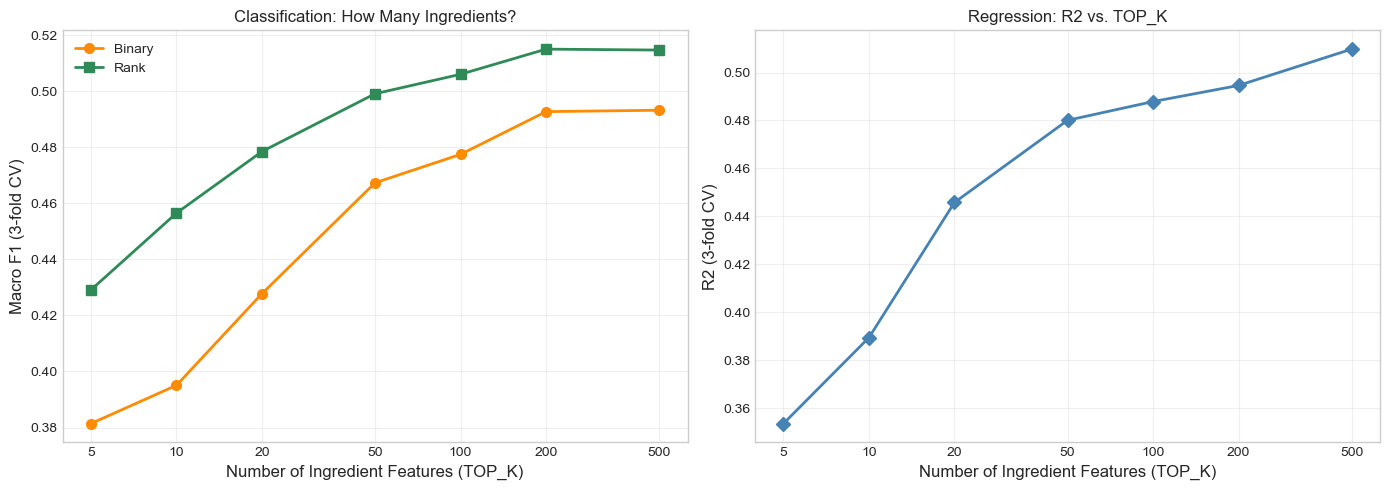

 TOP_K   Binary F1     Rank F1     Rank R2
------------------------------------------
     5      0.3814      0.4291      0.3535
    10      0.3951      0.4565      0.3894
    20      0.4278      0.4785      0.4458
    50      0.4673      0.4991      0.4801
   100      0.4774      0.5060      0.4879
   200      0.4927      0.5150      0.4946
   500      0.4932      0.5147      0.5098


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(topk_values, binary_f1_scores, 'o-', color='darkorange', lw=2, markersize=7, label='Binary')
ax.plot(topk_values, rank_f1_scores, 's-', color='seagreen', lw=2, markersize=7, label='Rank')
ax.set_xlabel('Number of Ingredient Features (TOP_K)', fontsize=12)
ax.set_ylabel('Macro F1 (3-fold CV)', fontsize=12)
ax.set_title('Classification: How Many Ingredients?', fontsize=12)
ax.set_xscale('log'); ax.set_xticks(topk_values)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(topk_values, regression_r2_scores, 'D-', color='steelblue', lw=2, markersize=7)
ax.set_xlabel('Number of Ingredient Features (TOP_K)', fontsize=12)
ax.set_ylabel('R2 (3-fold CV)', fontsize=12)
ax.set_title('Regression: R2 vs. TOP_K', fontsize=12)
ax.set_xscale('log'); ax.set_xticks(topk_values)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'topk_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"TOP_K":>6}  {"Binary F1":>10}  {"Rank F1":>10}  {"Rank R2":>10}')
print('-' * 42)
for k, bf, rf, r2 in zip(topk_values, binary_f1_scores, rank_f1_scores, regression_r2_scores):
    print(f'{k:>6}  {bf:>10.4f}  {rf:>10.4f}  {r2:>10.4f}')

### Interpretation — TOP_K Sensitivity

- **TOP_K = 5**: Very low F1. The 5 most common ingredients appear everywhere and are not discriminative.
- **TOP_K = 50–100**: Major jump — class-specific markers (citric acid, corn syrup, palm oil) enter the feature set.
- **TOP_K = 200–500**: Diminishing returns but still improving.
- **Rank consistently beats Binary** — confirming that ingredient position carries additional signal.
- **Conclusion: ~200 ingredients is a good balance** of performance vs. computational cost.

---
## 8. Bonus — Weighted Ingredient FPro from `GroceryDB_IgFPro.csv`

The dataset includes **pre-computed per-ingredient FPro scores**. How do they differ from our approach?

| | Our approaches (Sections 5–6) | IgFPro (this section) |
|---|---|---|
| **Input** | Raw ingredient lists | Pre-computed per-ingredient scores |
| **Method** | ML learns which ingredients matter | Lookup table + weighted average |
| **Limitation** | Needs top-K restriction | Only covers ~10K known ingredients |
| **Value** | Discovers patterns independently | Strong baseline / validation |

We compute a **rank-weighted average** of per-ingredient FPro scores as a validation check.

In [24]:
igfpro_lookup = dict(zip(igfpro['general_name'].str.lower().str.strip(),
                          igfpro['ingred_FPro']))

def compute_weighted_igfpro(ingred_list):
    total_w, weighted_f = 0.0, 0.0
    for rank, ing in enumerate(ingred_list, start=1):
        if ing in igfpro_lookup:
            w = 1.0 / rank
            weighted_f += w * igfpro_lookup[ing]
            total_w += w
    return weighted_f / total_w if total_w > 0 else np.nan

df_clean['weighted_igfpro'] = df_clean['ingred_list'].apply(compute_weighted_igfpro)
valid = df_clean.dropna(subset=['weighted_igfpro'])
r_ig, p_ig = stats.pearsonr(valid['weighted_igfpro'], valid['f_FPro'])

print(f'Matched: {valid.shape[0]:,} / {df_clean.shape[0]:,} products')
print(f'Pearson r (weighted IgFPro vs product FPro): {r_ig:.4f}  (p = {p_ig:.2e})')

Matched: 23,112 / 26,012 products
Pearson r (weighted IgFPro vs product FPro): 0.6633  (p = 0.00e+00)


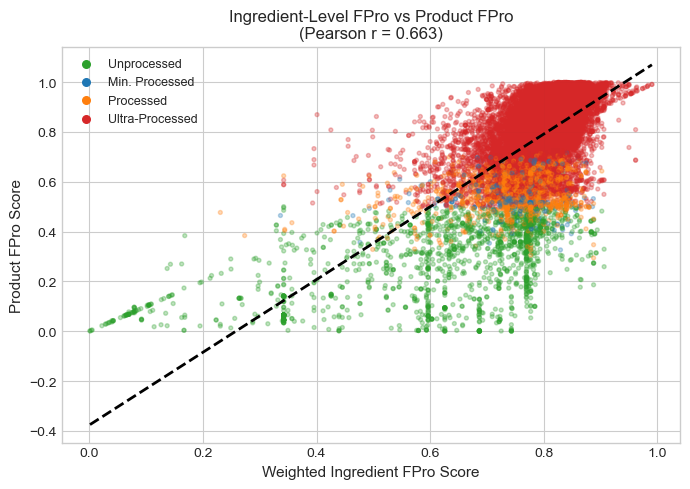

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(valid['weighted_igfpro'], valid['f_FPro'],
           c=[NOVA_COLORS[c] for c in valid['f_FPro_class']], alpha=0.3, s=8)
m, b = np.polyfit(valid['weighted_igfpro'], valid['f_FPro'], 1)
x_r = np.linspace(valid['weighted_igfpro'].min(), valid['weighted_igfpro'].max(), 200)
ax.plot(x_r, m*x_r + b, 'k--', lw=2)
ax.set_xlabel('Weighted Ingredient FPro Score', fontsize=11)
ax.set_ylabel('Product FPro Score', fontsize=11)
ax.set_title(f'Ingredient-Level FPro vs Product FPro\n(Pearson r = {r_ig:.3f})', fontsize=12)
for cls, lbl in CLASS_LABELS.items():
    ax.scatter([], [], c=NOVA_COLORS[cls], label=lbl, s=30)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'weighted_igfpro_vs_fpro.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation — Weighted IgFPro

- **r = 0.66**: Strong correlation! The pre-computed ingredient scores are highly predictive of product FPro.
- This **validates our approach**: if ingredient-level processing scores correlate well with product scores, then our ML models that learn ingredient patterns are capturing real signal.
- The IgFPro dataset is a useful hand-crafted feature, but our ML approaches can generalize to new ingredients not in the lookup table.

---
## 9. Results Summary & Next Steps

In [26]:
print('=' * 65)
print('RESULTS SUMMARY — Notebook 01: EDA & Ingredient Analysis')
print('=' * 65)
print()
print('--- Price vs FPro ---')
print(f'  Pearson r = {pearson_r:.4f}, Spearman r = {spearman_r:.4f}')
print(f'  -> Ultra-processed foods are cheaper per calorie')
print()
print('--- Binary Ingredient Features (Classification) ---')
print(f'  RF  Macro F1 = {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')
print(f'  LR  Macro F1 = {cv_lr_f1.mean():.4f} +/- {cv_lr_f1.std():.4f}')
print()
print('--- Rank Ingredient Features ---')
print(f'  RF Classification F1 = {cv_rank_f1.mean():.4f} +/- {cv_rank_f1.std():.4f}')
print(f'  RF Regression R2     = {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
print(f'  RF Regression RMSE   = {(-cv_rmse).mean():.4f} +/- {(-cv_rmse).std():.4f}')
print(f'  Ridge Regression R2  = {cv_ridge_r2.mean():.4f} +/- {cv_ridge_r2.std():.4f}')
print()
print('--- Weighted Ingredient FPro ---')
print(f'  Pearson r = {r_ig:.4f}')
print()
print('--- TOP_K Sensitivity ---')
for k, bf, rf in zip(topk_values, binary_f1_scores, rank_f1_scores):
    print(f'  K={k:<4}  Binary F1={bf:.3f}  Rank F1={rf:.3f}')
print('=' * 65)

RESULTS SUMMARY — Notebook 01: EDA & Ingredient Analysis

--- Price vs FPro ---
  Pearson r = -0.2457, Spearman r = -0.3528
  -> Ultra-processed foods are cheaper per calorie

--- Binary Ingredient Features (Classification) ---
  RF  Macro F1 = 0.5109 +/- 0.0019
  LR  Macro F1 = 0.4787 +/- 0.0041

--- Rank Ingredient Features ---
  RF Classification F1 = 0.5347 +/- 0.0085
  RF Regression R2     = 0.5196 +/- 0.0105
  RF Regression RMSE   = 0.1585 +/- 0.0015
  Ridge Regression R2  = 0.3608 +/- 0.0088

--- Weighted Ingredient FPro ---
  Pearson r = 0.6633

--- TOP_K Sensitivity ---
  K=5     Binary F1=0.381  Rank F1=0.429
  K=10    Binary F1=0.395  Rank F1=0.456
  K=20    Binary F1=0.428  Rank F1=0.478
  K=50    Binary F1=0.467  Rank F1=0.499
  K=100   Binary F1=0.477  Rank F1=0.506
  K=200   Binary F1=0.493  Rank F1=0.515
  K=500   Binary F1=0.493  Rank F1=0.515


### What this notebook established (Checkpoint 2: EDA & Feature Engineering)

1. **FPro is learnable from ingredients:** Both binary and rank features capture real signal (macro F1 > 0.5, R2 > 0.5).
2. **Rank encoding > Binary encoding:** Ingredient position adds info beyond presence/absence.
3. **~200 ingredients is the sweet spot** (shown by TOP_K curve).
4. **Price is a weak supplementary signal** (r = -0.25).
5. **Store matters:** Whole Foods is least processed, Target most.
6. **Category matters:** Produce/meat are low FPro; candy/soda are high FPro.
7. **Class 1 (culinary ingredients) is hardest** to classify.

### Next Steps (Notebook 02: Modeling)

The main model will use the **12 nutrition elements to predict FPro score**. This is the core model because:
- Nutrition data is available for all products (not just those with ingredient lists)
- It can be applied to other datasets (e.g., French CIQUAL) that have nutrition but no ingredient lists
- It mirrors the original FoodProX approach but we train our own independent model

Notebook 02 will cover: nutrition-based regression & classification, hyperparameter tuning, model comparison, and feature importance.